# Setup

In [1]:
from statasetup import *


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      18.0
___/   /   /___/   /   /___/       BE—Basic Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-STATA-PC        https://www.stata.com
                                   979-696-4600        stata@stata.com

Stata license: Unlimited-user network, expiring 17 Sep 2027
Serial number: 301909300944
  Licensed to: StataNow/BE 19.5
               StataNow/BE 19.5

Notes:
      1. Unicode is supported; see help unicode_advice.


In [14]:
%%stata
use "Datasets\asg1\PlannedEnv_4countries.dta",clear

# One way ANOVA

## Descriptive Analysis


. * Do a bit of descriptive analysis (check missing values, coding scheme) by w
> hich investigation of the two variable of interest is attempted
. codebook country

-------------------------------------------------------------------------------
country                                                             (unlabeled)
-------------------------------------------------------------------------------

                  Type: Numeric (double)
                 Label: countrylabel

                 Range: [1,4]                         Units: 1
         Unique values: 4                         Missing .: 1/801

            Tabulation: Freq.   Numeric  Label
                          199         1  Spain
                          200         2  India
                          200         3  US
                          201         4  Mexico
                            1         .  

. bysort country: sum behavior if country != ., d

-------------------------------------------------------

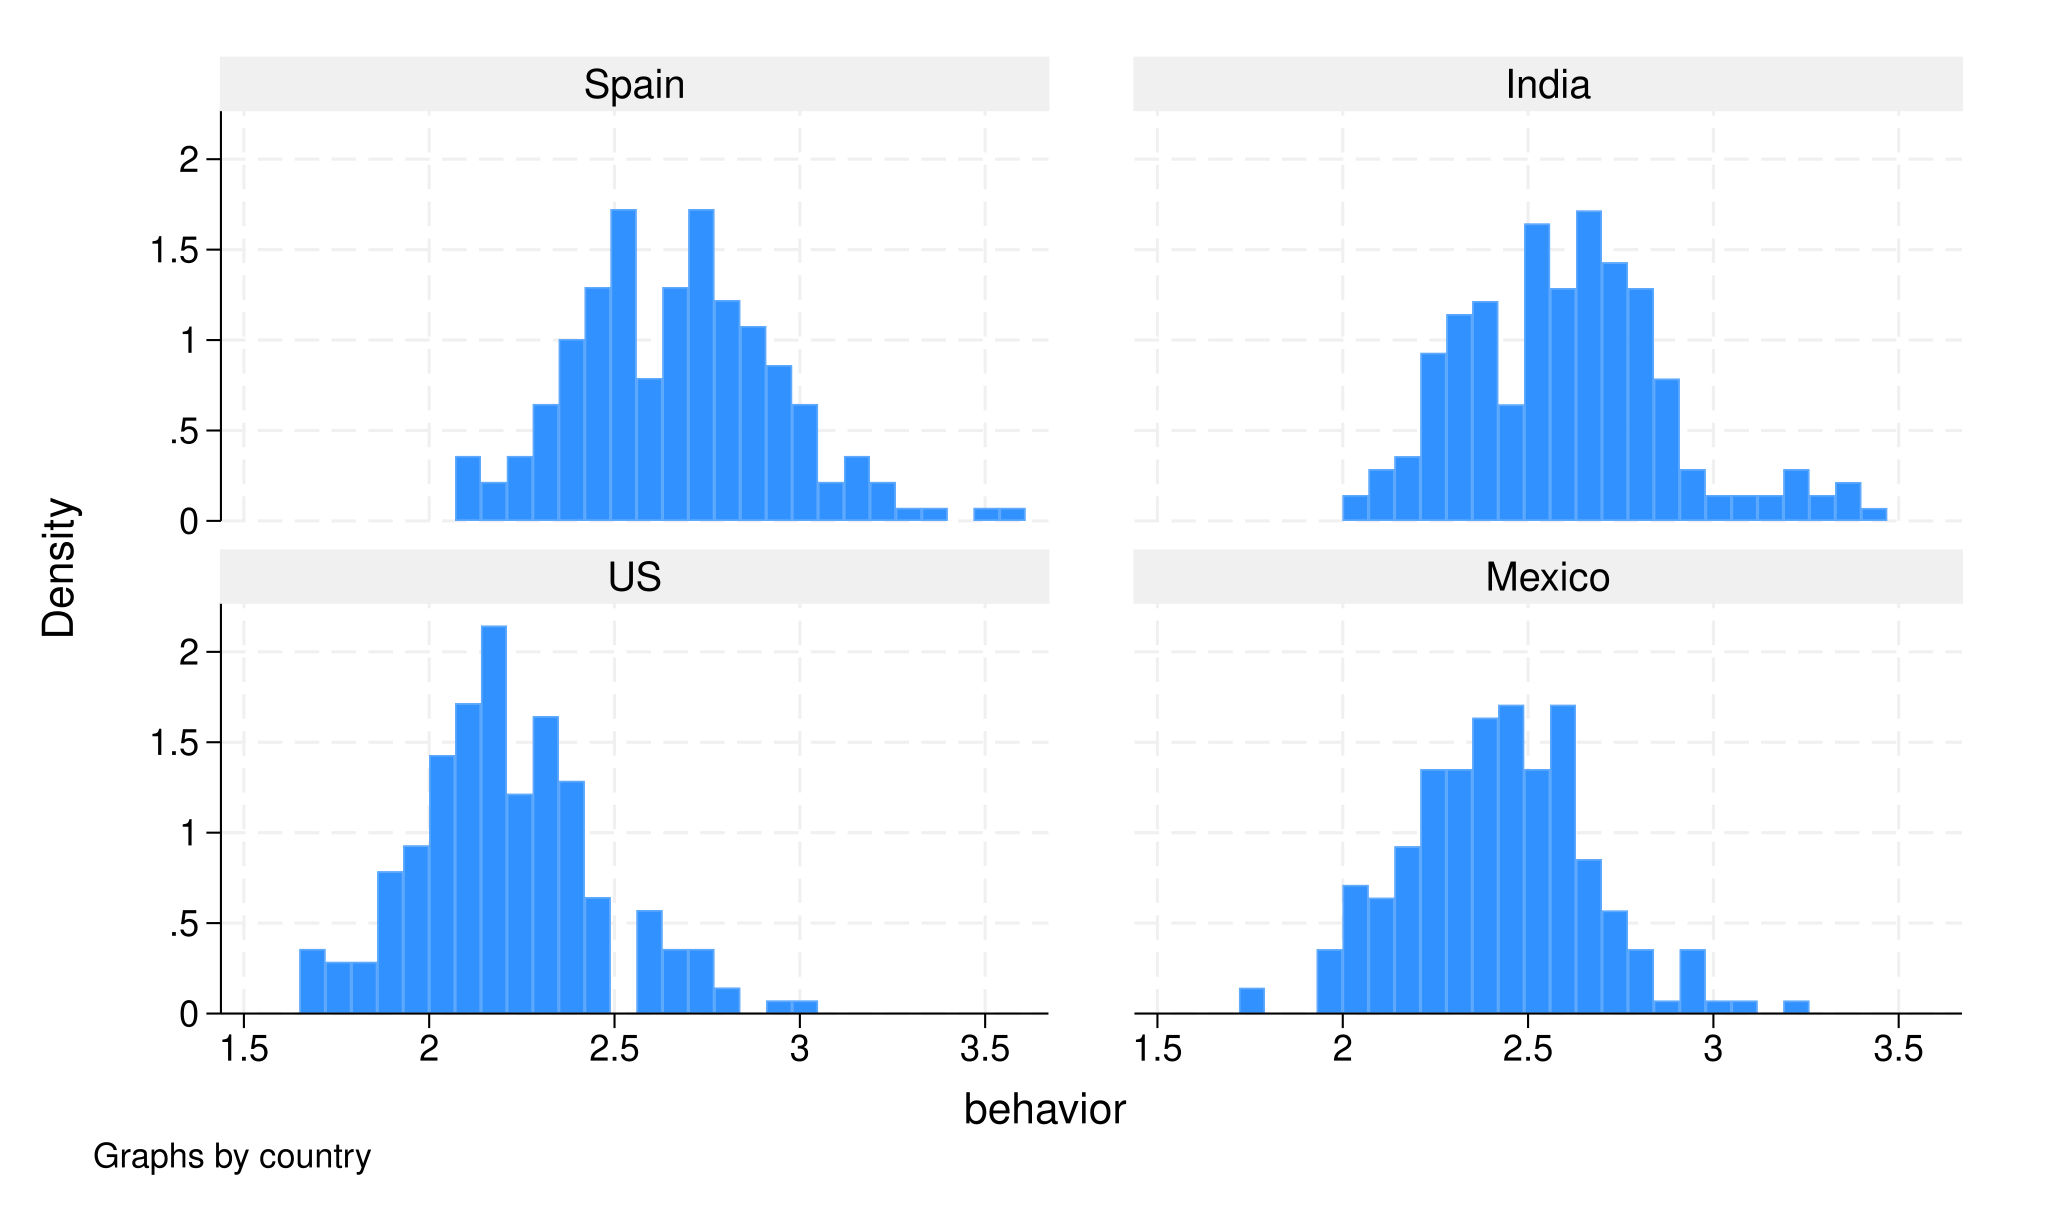

In [18]:
%%stata
* Do a bit of descriptive analysis (check missing values, coding scheme) by which investigation of the two variable of interest is attempted
codebook country
bysort country: sum behavior if country != ., d
hist behavior, by(country)
list count behavior if behavior >=.

## Checking for normality

In [23]:
%%stata
* check/verify the distribution central part tallness
sktest behavior if country ==1
sktest behavior if country ==2
sktest behavior if country ==3
sktest behavior if country ==4

bysort country: swilk behavior


. * check/verify the distribution central part tallness
. sktest behavior if country ==1

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
    behavior |       199         0.0408         0.3609          5.06     0.0796

. sktest behavior if country ==2

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
    behavior |       200         0.0053         0.3398          8.00     0.0183

. sktest behavior if country ==3

Skewness and kurtosis tests for normality
                                                         ----- Joint test

## Performing a heterogeneity of variances test

In [6]:
%%stata
robvar(behavior), by(country)


            |         Summary of behavior
    country |        Mean   Std. dev.       Freq.
------------+------------------------------------
      Spain |   2.6669529   .27487569         199
      India |   2.6076151   .27605625         200
         US |   2.2037142   .24876457         200
     Mexico |   2.4197233   .24535415         201
------------+------------------------------------
      Total |   2.4741923   .31773319         800

W0  =  1.6160376   df(3, 796)     Pr > F = 0.18417302

W50 =  1.7191323   df(3, 796)     Pr > F = 0.16155231

W10 =  1.7023315   df(3, 796)     Pr > F = 0.16505076


## Perform **One Way ANOVA** and determine effect size

In [38]:
%%stata
anova behavior country
estat esize 


. anova behavior country

                         Number of obs =        800    R-squared     =  0.3246
                         Root MSE      =    .261615    Adj R-squared =  0.3220

                  Source | Partial SS         df         MS        F    Prob>F
              -----------+----------------------------------------------------
                   Model |  26.182521          3   8.7275071    127.52  0.0000
                         |
                 country |  26.182521          3   8.7275071    127.52  0.0000
                         |
                Residual |   54.48003        796   .06844225  
              -----------+----------------------------------------------------
                   Total |  80.662551        799   .10095438  

. estat esize 

Effect sizes for linear models

-----------------------------------------------------------------
             Source | Eta-squared     df     [95% conf. interval]
--------------------+-------------------------------------

## Post hoc analysis, on margin means and observed explained variance
1. **Observed means** calculated based on your data: `mean dependent, over(factor)` & `pwmean` & `pwcompare`
2. **Estimated marginal means** obtained by means of linear regression: `margins` & `pwcompare`

In [48]:
%%stata
mean behavior, over(country)
pwmean behavior, over(country) effect
pwmean behavior, over(country) mcompare(tukey) effect


. mean behavior, over(country)

Mean estimation                                  Number of obs = 800

--------------------------------------------------------------------
                   |       Mean   Std. err.     [95% conf. interval]
-------------------+------------------------------------------------
c.behavior@country |
            Spain  |   2.666953   .0194854      2.628704    2.705202
            India  |   2.607615   .0195201      2.569298    2.645932
               US  |   2.203714   .0175903      2.169185    2.238243
           Mexico  |   2.419723   .0173059      2.385753    2.453694
--------------------------------------------------------------------

. pwmean behavior, over(country) effect

Pairwise comparisons of means with equal variances

Over: country

------------------------------------------------------------------------------
             |                            Unadjusted           Unadjusted
    behavior |   Contrast   Std. err.      t    P>|t|     [95%

In [47]:
%%stata
margins country
margins country, pwcompare(effects)
margins country, pwcompare(effects) mcompare(bonferroni)


. margins country

Adjusted predictions                                       Number of obs = 800

Expression: Linear prediction, predict()

------------------------------------------------------------------------------
             |            Delta-method
             |     Margin   std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
     country |
      Spain  |   2.666953   .0185454   143.81   0.000     2.630549    2.703356
      India  |   2.607615    .018499   140.96   0.000     2.571303    2.643928
         US  |   2.203714    .018499   119.13   0.000     2.167402    2.240027
     Mexico  |   2.419723   .0184529   131.13   0.000     2.383501    2.455945
------------------------------------------------------------------------------

. margins country, pwcompare(effects)

Pairwise comparisons of adjusted predictions               Number of obs = 800

Expression: Linear prediction, predict()

----------

## Perform **Between-Subjects Factorial Anova**

In [11]:
%%stata
use "Datasets\asg1\Stereotype_threat.dta",clear

In [12]:
%%stata 
anova performance race##test_type
estat esize


. anova performance race##test_type

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
          ---------------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
                    race |         20          1          20      2.35  0.1446
               test_type |         45          1          45      5.29  0.0352
          race#test_type |         80          1          80      9.41  0.0074
                         |
                Residual |        136         16         8.5  
          ---------------+----------------------------------------------------
                   Total |        281         19   14.789474  

. estat esize

Effect sizes for linear models

----------------------

## **Post-hoc analysis** after Fac. Anova
 1. Following up on a meaningful interaction effect using EEMs


. margins race#test_type

Adjusted predictions                                        Number of obs = 20

Expression: Linear prediction, predict()

------------------------------------------------------------------------------
             |            Delta-method
             |     Margin   std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        race#|
   test_type |
      black #|
 diagnostic  |          4    1.30384     3.07   0.007     1.235982    6.764018
      black #|
non-diagn~c  |         11    1.30384     8.44   0.000     8.235982    13.76402
      white #|
 diagnostic  |         10    1.30384     7.67   0.000     7.235982    12.76402
      white #|
non-diagn~c  |          9    1.30384     6.90   0.000     6.235982    11.76402
------------------------------------------------------------------------------

. marginsplot

Variables that uniquely identify margins: race test_type

. margins race, 

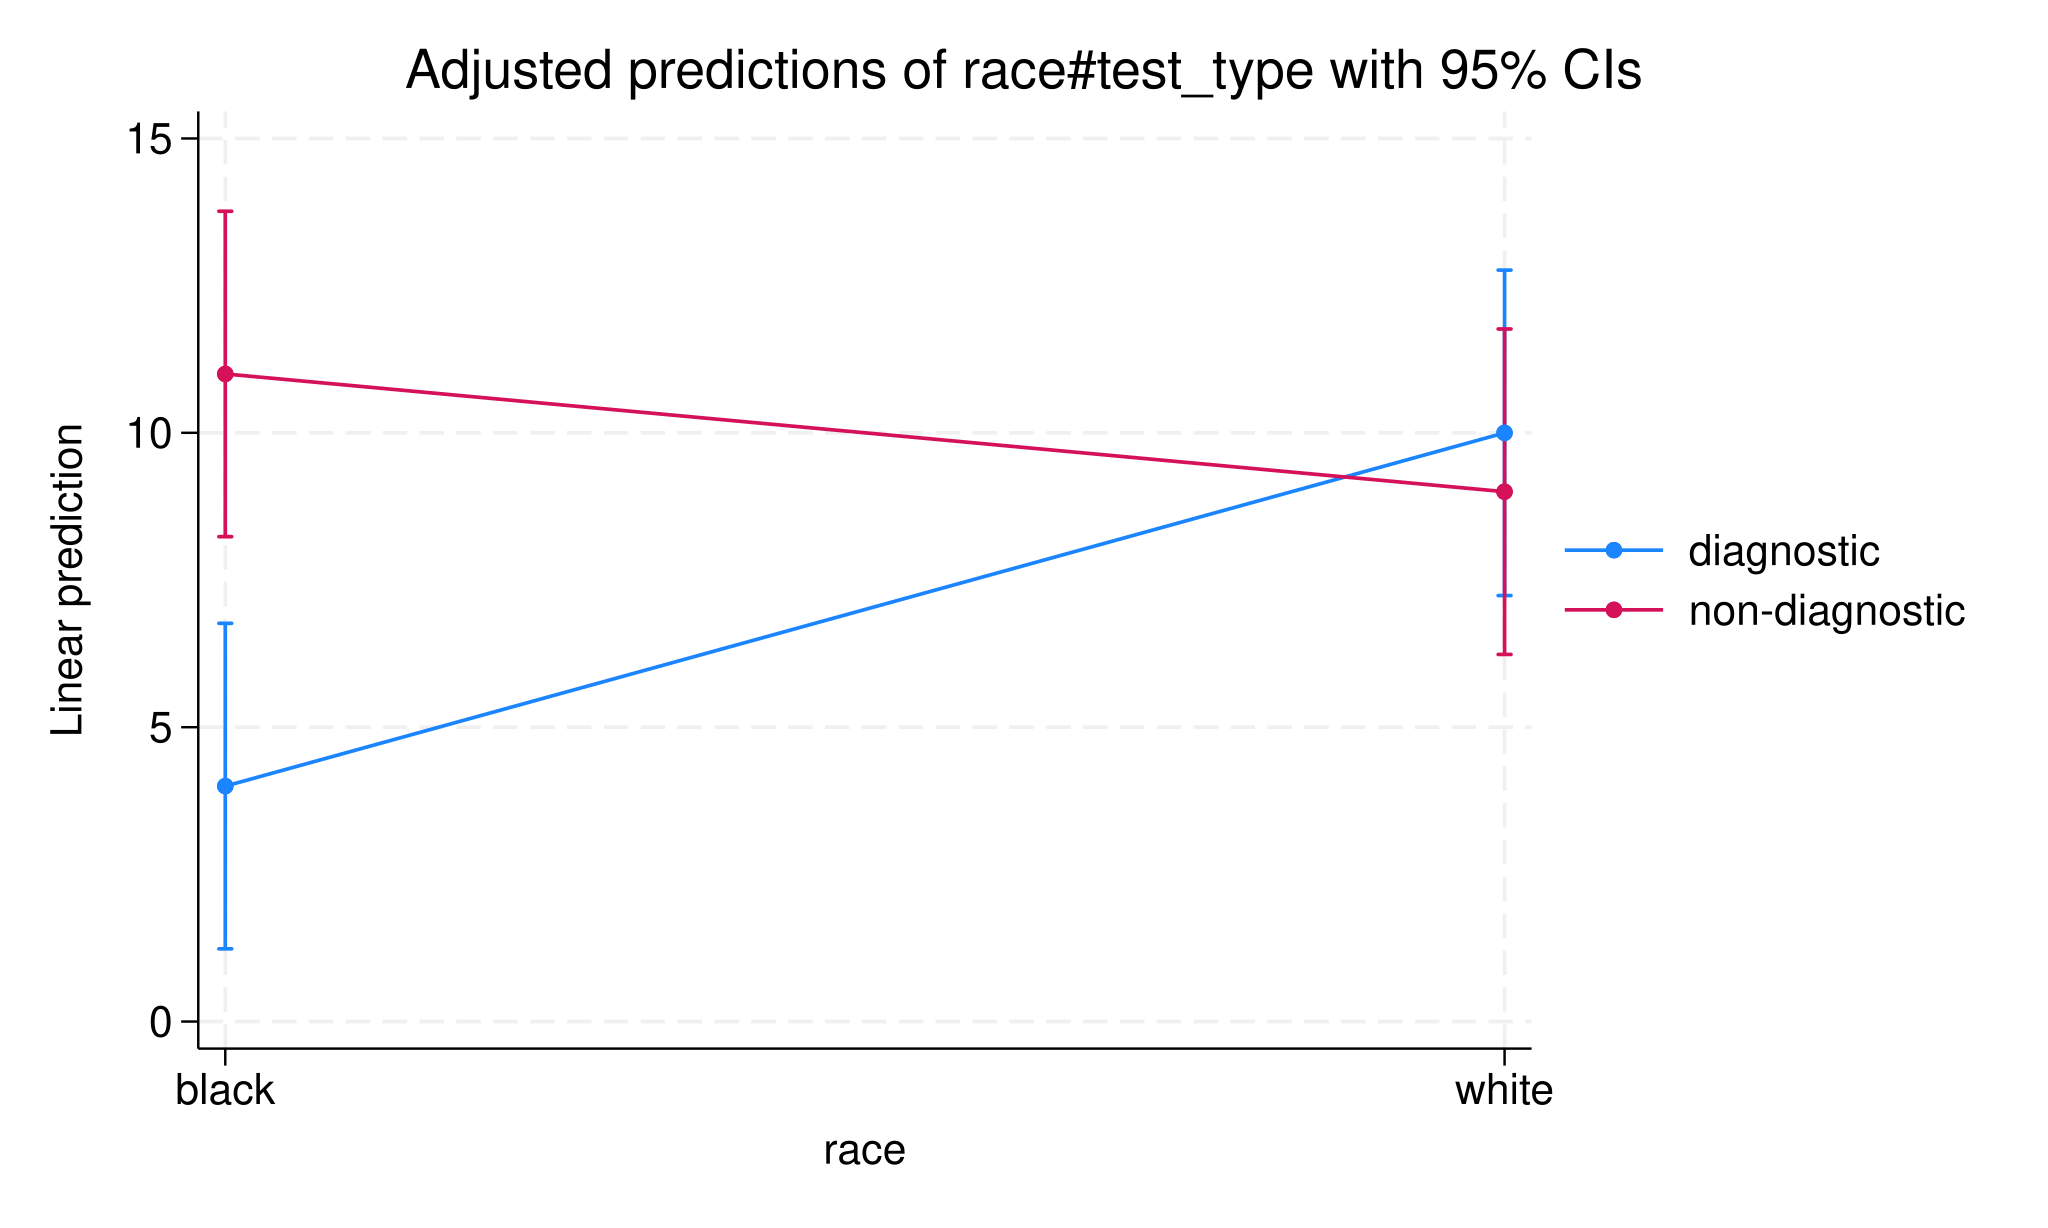

In [6]:
%%stata
margins race#test_type
marginsplot
margins race, at(test_type==1) pwcompare(effects)
margins race, at(test_type==2) pwcompare(effects)

2. Acting upon the meaningful interaction effect by using observed means

In [ ]:
%%stata 
pwmean performance if test_type==1, over(race) effect 
pwmean performance if test_type==2, over(race) effect 


. pwmean performance if test_type==1, over(race) effect 

Pairwise comparisons of means with equal variances

Over: race

------------------------------------------------------------------------------
             |                            Unadjusted           Unadjusted
 performance |   Contrast   Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        race |
      white  |
         vs  |
      black  |          6   1.843909     3.25   0.012     1.747938    10.25206
------------------------------------------------------------------------------

. pwmean performance if test_type==2, over(race) effect 

Pairwise comparisons of means with equal variances

Over: race

------------------------------------------------------------------------------
             |                            Unadjusted           Unadjusted
 performance |   Contrast   Std. err.      t    P>|t|     [95% conf. interval]
--------

## Perform **eta** and **eta partial** calculations

In [13]:
%%stata
estat esize


Effect sizes for linear models

-----------------------------------------------------------------
             Source | Eta-squared     df     [95% conf. interval]
--------------------+--------------------------------------------
              Model |   .5160142       3     .0621074    .6668826
                    |
               race |   .1282051       1            .    .4106325
          test_type |   .2486188       1            .    .5163395
     race#test_type |   .3703704       1     .0342347    .6055167
-----------------------------------------------------------------
Note: Eta-squared values for individual model terms are partial.


## Factorial ANOVA with empasis on interaction effects

In [117]:
%%stata
use "Datasets\asg1\Therapy.dta", clear

In [118]:
%%stata
anova efficiency gender_therapist##gender_client
estat esize


. anova efficiency gender_therapist##gender_client

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
 ------------------------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
             gender_th~t |         45          1          45      5.29  0.0352
             gender_cl~t |         20          1          20      2.35  0.1446
 gender_th~t#gender_cl~t |         80          1          80      9.41  0.0074
                         |
                Residual |        136         16         8.5  
 ------------------------+----------------------------------------------------
                   Total |        281         19   14.789474  

. estat esize

Effect sizes for linear models

-------

## **Post hoc** analysis on meaningful interaction effects
Whenever a meaningful interaction effect is identified one must assess a few things:
1. *For which specific levels the interaction remains meaningful*
    * In this case do retrieve the observed/estimated means just for the factor levels for which the analysis remained significant;
    * Second, do `margins meaningful factor, at(not meaningful factor)` to see for which level of the not meaningful factor the interaction holds
2. Calculate the interaction effect (the residual group means—as done manually in C3)
3. *The direction/orientation of the contrast as unveiled by the interaction effect* 

In [119]:
%%stata
* What is the combination of factor levels for which the interaction is meaningful calculated with EEM and OBS means
margins gender_therapist, at(gender_client==1) pwcompare(effect)
margins gender_therapist, at(gender_client==2) pwcompare(effect)

pwmean efficiency if gender_client==1, over(gender_therapist) effect mcompare(tukey)
pwmean efficiency if gender_client==2, over(gender_therapist) effect mcompare(tukey)


. * What is the combination of factor levels for which the interaction is meani
> ngful calculated with EEM and OBS means
. margins gender_therapist, at(gender_client==1) pwcompare(effect)

Pairwise comparisons of adjusted predictions                Number of obs = 20

Expression: Linear prediction, predict()
At: gender_client = 1

------------------------------------------------------------------------------
             |            Delta-method    Unadjusted           Unadjusted
             |   Contrast   std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
gender_the~t |
     female  |
         vs  |
       male  |          7   1.843909     3.80   0.002     3.091088    10.90891
------------------------------------------------------------------------------

. margins gender_therapist, at(gender_client==2) pwcompare(effect)

Pairwise comparisons of adjusted predictions                Number of obs = 20

Ex

In [129]:
%%stata
* Calculate the interaction effect (the residual group means—as done manually in C3)

drop res
anova efficiency gender_therapist##gender_client
predict res, residuals //calculates the residual for each data point and saves it to a variable called res
mean res, over(gender_client gender_therapist) 


. * Calculate the interaction effect (the residual group means—as done manually
>  in C3)
. 
. drop res

. anova efficiency gender_therapist##gender_client

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
 ------------------------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
             gender_th~t |         45          1          45      5.29  0.0352
             gender_cl~t |         20          1          20      2.35  0.1446
 gender_th~t#gender_cl~t |         80          1          80      9.41  0.0074
                         |
                Residual |        136         16         8.5  
 ------------------------+----------------------------------------------------
             


. margins gender_therapist, pwcompare(effect) mcompare(bonferroni)



Pairwise comparisons of predictive margins                  Number of obs = 20

Expression: Linear prediction, predict()

note: option bonferroni ignored since there is only one comparison
------------------------------------------------------------------------------
             |            Delta-method    Unadjusted           Unadjusted
             |   Contrast   std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
gender_the~t |
     female  |
         vs  |
       male  |          3    1.30384     2.30   0.035     .2359817    5.764018
------------------------------------------------------------------------------

. marginsplot

Variables that uniquely identify margins: _pw1

      i_pw enumerates all pairwise comparisons; _pw0 enumerates the reference
          categories; _pw1 enumerates the comparison categories.

. 


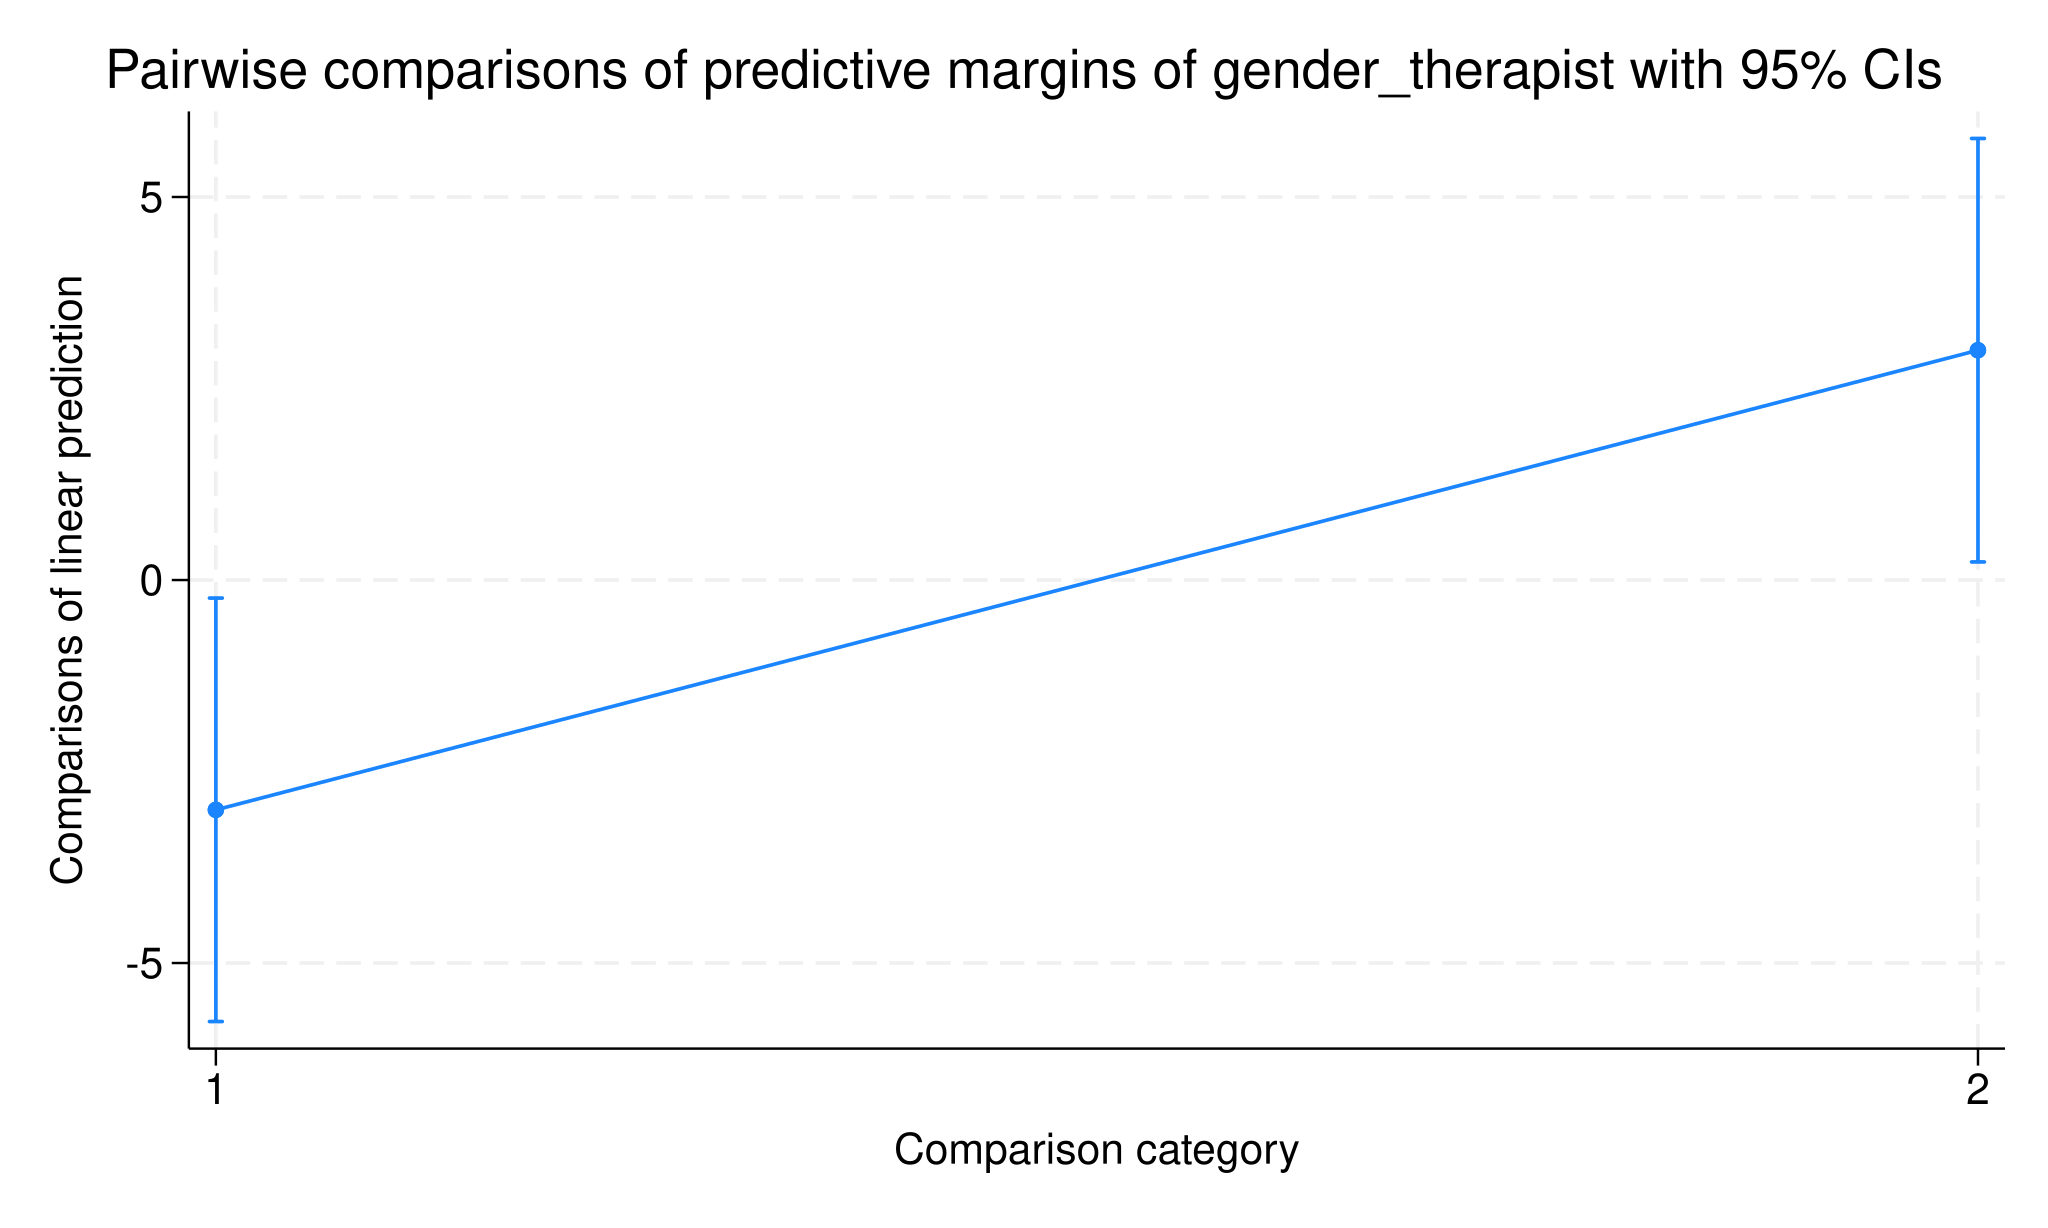

In [51]:
%%stata
margins gender_therapist, pwcompare(effect) mcompare(bonferroni)
marginsplot


. margins gender_client#gender_therapist



Adjusted predictions                                        Number of obs = 20

Expression: Linear prediction, predict()

------------------------------------------------------------------------------
             |            Delta-method
             |     Margin   std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
gender_cli~t#|
gender_the~t |
  male#male  |          4    1.30384     3.07   0.007     1.235982    6.764018
male#female  |         11    1.30384     8.44   0.000     8.235982    13.76402
female#male  |         10    1.30384     7.67   0.000     7.235982    12.76402
     female #|
     female  |          9    1.30384     6.90   0.000     6.235982    11.76402
------------------------------------------------------------------------------

. margins gender_client#gender_therapist, pwcompare(effects) mcompare(bonferron
> i)

Pairwise comparisons of adjusted predictions                Number of obs 

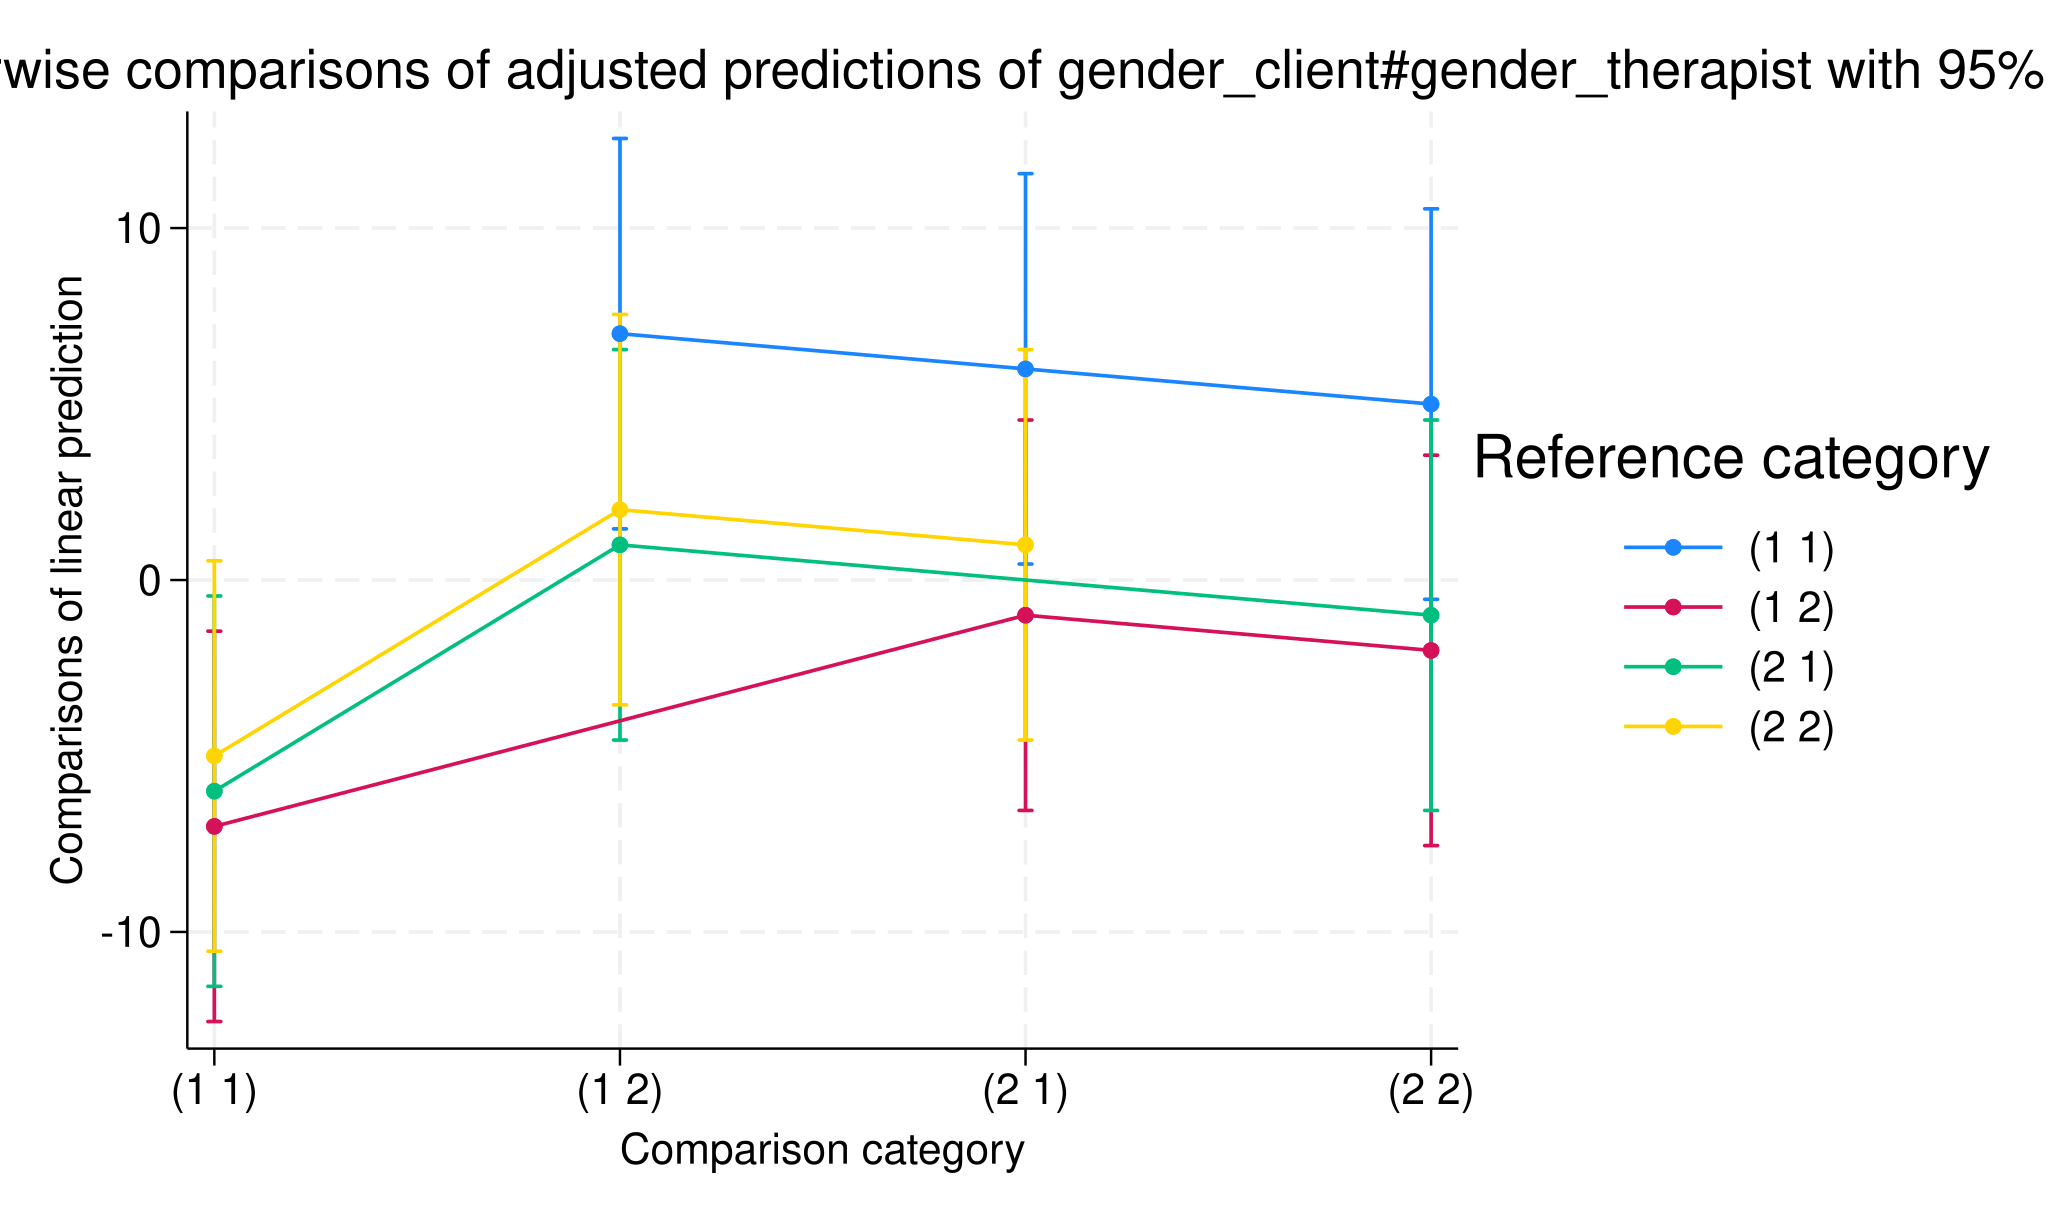

In [58]:
%%stata
margins gender_client#gender_therapist
margins gender_client#gender_therapist, pwcompare(effects) mcompare(bonferroni)
marginsplot